In [5]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset,DataLoader
from json import loads
from tokenizers import Tokenizer
from google.colab import drive
drive.mount('/content/drive/')
tokenizer = Tokenizer.from_file("/content/drive/MyDrive/token4.pt")
with open("/content/drive/MyDrive/chat_train.txt","r",encoding="utf-8") as f:
    data = f.read()

data = tokenizer.encode(data)
len_token = len(data.ids)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:",device)
with open("/content/drive/MyDrive/token4.pt","r",encoding='utf-8') as f:
    file = f.read()
file = loads(file)
vocab_size = tokenizer.get_vocab_size()

seq_len = 64
num_sequences = (len_token - 1) // seq_len
usable = num_sequences * seq_len
flat_ids = torch.tensor(data.ids[:usable],dtype=torch.long)
token_id = flat_ids.reshape(num_sequences,seq_len)
target_id = torch.roll(flat_ids,-1).reshape(num_sequences,seq_len)
assert token_id.max().item() < vocab_size, "a token id is >= vocab_size"
assert target_id.max().item() < vocab_size, "a target id is >= vocab_size"

X_train = token_id
Y_train = target_id

tokens_train = TensorDataset(X_train,Y_train)

with open("/content/drive/MyDrive/chat_val.txt","r",encoding="utf-8") as f:
    data2 = f.read()

data2 = tokenizer.encode(data2)
len_token2 = len(data2.ids)
num_sequences2 = (len_token2 - 1) // seq_len
usable2 = num_sequences2 * seq_len
flat_ids2 = torch.tensor(data2.ids[:usable2],dtype=torch.long)
token_id2 = flat_ids2.reshape(num_sequences2,seq_len)
target_id2 = torch.roll(flat_ids2,-1).reshape(num_sequences2,seq_len)
assert token_id2.max().item() < vocab_size, "a token id is >= vocab_size"
assert target_id2.max().item() < vocab_size, "a target id is >= vocab_size"
X_val = token_id2
Y_val = target_id2

tokens_val = TensorDataset(X_val,Y_val)

d = 320
class transformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.wq = nn.Linear(d,d)
        self.wk = nn.Linear(d,d)
        self.wv = nn.Linear(d,d)

        self.final = nn.Linear(d,d)
        self.drop = nn.Dropout(p = 0.2)
        self.layer_norm = nn.LayerNorm(d)
        self.soft = nn.Softmax(dim=-1)
        self.layer_norm2 = nn.LayerNorm(d)
        self.ffn = nn.Sequential(
            nn.Linear(d,d*2),
            self.drop,
            nn.GELU(),
            nn.Linear(d*2,d)
        )
    def forward(self,x):
        batch_size = x.shape[0]
        seq_len = x.shape[1]

        q = self.wq(x)
        k = self.wk(x)
        v = self.wv(x)

        q = q.view(batch_size,seq_len,10,d//10)
        k = k.view(batch_size,seq_len,10,d//10)
        v = v.view(batch_size,seq_len,10,d//10)

        q = q.transpose(1,2)
        k = k.transpose(1,2)
        v = v.transpose(1,2)

        scores = q@k.transpose(-2,-1)
        scores = scores/(torch.sqrt(torch.tensor(d//10,device=device)))

        mask = torch.ones(seq_len,seq_len,device=device)
        triangle = torch.triu(mask,diagonal=1).bool()
        scores = scores.masked_fill(triangle,float("-inf"))
        prob = self.soft(scores)
        attention = prob@v
        attention = attention.transpose(1,2).reshape(batch_size,seq_len,d)
        output = self.final(attention)
        output = output + x

        output = self.layer_norm(output)
        feed = self.ffn(output)
        feed = feed + output
        feed = self.layer_norm2(feed)

        return feed

block = nn.ModuleList(
    [
        transformer(),
        transformer(),
        nn.Embedding(vocab_size,d),
        nn.Embedding(seq_len,d),
        nn.LayerNorm(d),
        nn.Linear(d,vocab_size)
    ]
)
block.to(device)
optimizer = torch.optim.AdamW(block.parameters(),lr = 5e-4,weight_decay=0.1,betas=(0.9,0.95))

BATCH_SIZE = 64
pin = (device.type == "cuda")
train_dataset = DataLoader(tokens_train,shuffle=True,batch_size=BATCH_SIZE,pin_memory=pin)
test_dataset = DataLoader(tokens_val,shuffle=True,batch_size=BATCH_SIZE,pin_memory=pin)
loss_t = nn.CrossEntropyLoss()

train_losses = []
val_losses = []

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Using device: cuda


In [6]:

for _ in range(20):
    block.train()
    epoch_train_loss = torch.zeros((), device=device)
    train_batches = 0
    for X_t,Y_t in train_dataset:
        X_t = X_t.to(device,non_blocking=True)
        Y_t = Y_t.to(device,non_blocking=True)
        embendings = block[2](X_t)

        positions = torch.arange(0,X_t.size(1),dtype=torch.long,device=device).unsqueeze(0).expand(X_t.size(0),-1)
        position_embendings = block[3](positions)

        X_t = embendings+position_embendings
        x = block[0](X_t)
        for i in range(1,2):
            x = block[i](x)
        norm = block[4](x)
        output = block[5](norm)
        output = output.reshape(-1,vocab_size)
        loss = loss_t(output,Y_t.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(block.parameters(), max_norm=1.0)
        optimizer.step()
        optimizer.zero_grad()

        epoch_train_loss += loss.detach()
        train_batches += 1

    avg_train_loss = (epoch_train_loss / train_batches).item()
    train_losses.append(avg_train_loss)
    with torch.no_grad():
        block.eval()
        epoch_val_loss = torch.zeros((), device=device)
        val_batches = 0
        for X_t,Y_t in test_dataset:
            X_t = X_t.to(device,non_blocking=True)
            Y_t = Y_t.to(device,non_blocking=True)
            embendings = block[2](X_t)
            positions = torch.arange(0,X_t.size(1),dtype=torch.long,device=device).unsqueeze(0).expand(X_t.size(0),-1)
            position_embendings = block[3](positions)

            X_t = embendings+position_embendings
            x = block[0](X_t)
            for i in range(1,2):
                x = block[i](x)
            norm = block[4](x)
            output = block[5](norm)
            output = output.reshape(-1,vocab_size)
            loss = loss_t(output,Y_t.reshape(-1))

            epoch_val_loss += loss.detach()
            val_batches += 1

        avg_val_loss = (epoch_val_loss / val_batches).item()
        val_losses.append(avg_val_loss)
        if _ % 16 == 0:
          print(f"Epoch {_} | train loss: {avg_train_loss:.4f} | val loss: {avg_val_loss:.4f}")



Epoch 0 | train loss: 3.2210 | val loss: 1.9751
Epoch 16 | train loss: 0.4446 | val loss: 0.8223


In [ ]:
import torch.nn.functional as F
@torch.no_grad()
def generate(text, temperature=0.5, top_k=20, max_new=60):
    block.eval()
    eos = tokenizer.token_to_id("<eos>")   # change to your EOS token, or None
    ids = tokenizer.encode(text, add_special_tokens=False).ids[-seq_len:]
    n_prompt = len(ids)
    for _ in range(max_new):
        x = torch.tensor(ids[-seq_len:], device=device).unsqueeze(0)
        pos = torch.arange(x.size(1), device=device).unsqueeze(0)
        h = block[2](x) + block[3](pos)
        h = block[1](block[0](h))
        logits = block[5](block[4](h))[0, -1] / temperature
        kth = torch.topk(logits, top_k).values[-1]
        logits[logits < kth] = float("-inf")
        nxt = torch.multinomial(F.softmax(logits, -1), 1).item()
        if eos is not None and nxt == eos:
            break
        ids.append(nxt)
    return tokenizer.decode(ids[n_prompt:])

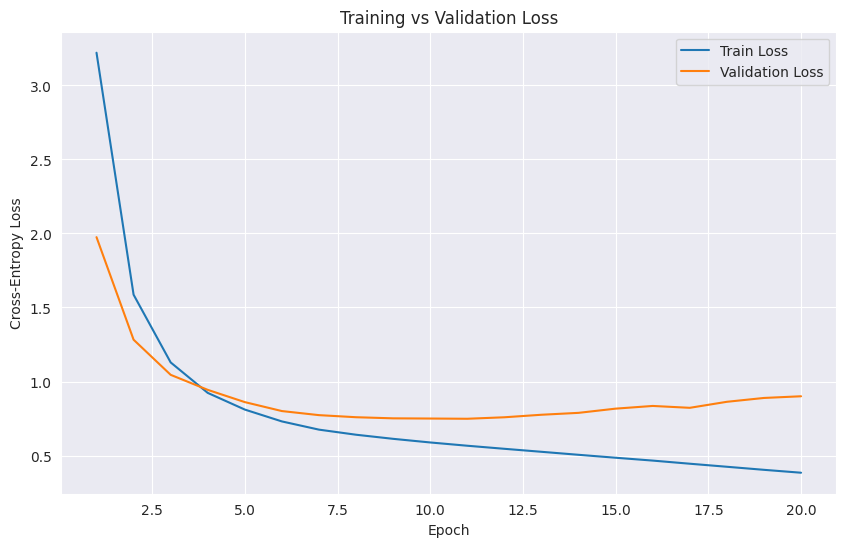

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
plt.figure(figsize=(10,6))
plt.plot(range(1, len(train_losses)+1), train_losses, label="Train Loss")
plt.plot(range(1, len(val_losses)+1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

Please run the above cell, then re-run the cell with the `while True:` loop. The new traceback should point to the exact line in your model's forward pass where the CUDA error occurs, helping us pinpoint the problem.

In [9]:
total_params = sum(p.numel() for p in block.parameters())
trainable_params = sum(p.numel() for p in block.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 2,948,560
Trainable parameters: 2,948,560


In [10]:
while True:
    prompt = input("You: ")
    if prompt.lower() == "quit" or prompt.lower() == "end":
        break
    response = generate(prompt + "\n")
    print(response)

You: hello
Hello, Kenji! What would you like to talk about?
You: i love pizza
Yum! I can't eat, but I love hearing about food.
You: tell me a joke
Why did the computer go to the doctor? It had a virus.
You: who are you
Someone who is learning how language models work built me and trained me on conversations.
You: i am your friend
Hi there! All good here. How's your day?
You: can you impress someone
I'm just a small chatbot for friendly conversation, so I don't know much about that. Want to chat about something else?
You: yes
Thanks for telling me! How do you feel about windy days?
You: those are great but until dust comes in eyes
That's cool! What do you like most about running?
You: water 
I can't see outside, but I hope you enjoy it. What do you like to do in cold weather?
You: wear warm cloths
I'm glad you're feeling excited! Tell me more.
You: if someone hate you what will you do
I can't taste anything, but it sounds yummy. What's your favorite way to have it?
You: can you taste fo

In [11]:
torch.save(block.state_dict(), "/content/drive/MyDrive/chatbot.pt")